# Multi-task LoRA vs Single-gene LoRA — 6 Gene Comparison

Comparing per-gene performance between:
- **Multi-task LoRA**: One model jointly predicts all 400 genes
- **Single-gene LoRA**: Separate model per gene

**Test genes across 3 tiers:**

| Gene | idx | Tier | Expected multi-task r |
|------|-----|------|----------------------|
| VIM     | 1093 | high-R | ~0.82 |
| CEACAM6 | 1945 | high-R | ~0.77 |
| TPM1    | 1553 | mid-R  | ~0.30 |
| NUPR1   | 1624 | mid-R  | ~0.29 |
| DDX5    | 1778 | low-R  | ~0.14 |
| CIRBP   | 1848 | low-R  | ~0.18 |

**Loss types:** MSE, Mixed (c=0.2, v=0.05)

**Key questions:**
1. Does single-gene LoRA help high-R genes more (where signal exists)?
2. Does multi-task LoRA hurt low-R genes (noise disruption)?
3. Is mixed loss effect consistent across tiers?

## 1. Setup

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi':           120,
    'font.size':             10,
    'axes.spines.top':       False,
    'axes.spines.right':     False,
    'legend.frameon':        False,
})

PROJECT = Path('/hpc/group/jilab/tc459/MorphPT')

# Sorted by tier, high to low expected r
GENES_TO_COMPARE = [
    ('VIM',     1093, 'high-R'),
    ('CEACAM6', 1945, 'high-R'),
    ('TPM1',    1553, 'mid-R'),
    ('NUPR1',   1624, 'mid-R'),
    ('DDX5',    1778, 'low-R'),
    ('CIRBP',   1848, 'low-R'),
]

LOSS_VARIANTS = {
    'mse':   'mse',
    'mixed': 'mixed_c0.2_v0.05',
}

TIER_ORDER  = ['high-R', 'mid-R', 'low-R']
TIER_COLORS = {'high-R': '#2d6a4f', 'mid-R': '#F0B441', 'low-R': '#C44E52'}

print(f'Comparing {len(GENES_TO_COMPARE)} genes '
      f'across {len(LOSS_VARIANTS)} loss types '
      f'= {len(GENES_TO_COMPARE) * len(LOSS_VARIANTS)} comparisons')

Comparing 6 genes across 2 loss types = 12 comparisons


## 2. Helper functions

In [4]:
def load_multi_task_results(loss_dir_suffix):
    csv_path = (PROJECT / 'experiments' /
                f'lora_probing_crc_multi_10.0x_{loss_dir_suffix}' /
                'multi_lora_hybrid_results.csv')
    if not csv_path.exists():
        print(f'  WARNING: {csv_path} not found')
        return {}

    df = pd.read_csv(csv_path)

    if 'test_pearson_s42' in df.columns:
        col = 'test_pearson_s42'
    elif 'test_pearson_mean' in df.columns:
        col = 'test_pearson_mean'
    else:
        print(f'  Cols: {df.columns.tolist()}')
        return {}

    return dict(zip(df['gene_name'], df[col]))


def load_single_gene_results(gene_name, loss_dir_suffix):
    json_path = (PROJECT / 'experiments' /
                 f'lora_single_crc_10.0x_{loss_dir_suffix}' /
                 gene_name / 'results.json')

    if not json_path.exists():
        return None
    return json.loads(json_path.read_text())

## 3. Diagnostic — check files exist

In [5]:
print('Expected files:\n')
for loss_label, loss_suffix in LOSS_VARIANTS.items():
    print(f'  Loss = {loss_label}:')

    multi_path = (PROJECT / 'experiments' /
                  f'lora_probing_crc_multi_10.0x_{loss_suffix}' /
                  'multi_lora_hybrid_results.csv')
    status = '✓' if multi_path.exists() else '✗'
    print(f'    {status} Multi: lora_probing_crc_multi_10.0x_{loss_suffix}/')

    for gene_name, _, tier in GENES_TO_COMPARE:
        single_path = (PROJECT / 'experiments' /
                       f'lora_single_crc_10.0x_{loss_suffix}' /
                       gene_name / 'results.json')
        status = '✓' if single_path.exists() else '✗'
        print(f'    {status} Single {gene_name:<8} [{tier}]')
    print()

Expected files:

  Loss = mse:
    ✓ Multi: lora_probing_crc_multi_10.0x_mse/
    ✓ Single VIM      [high-R]
    ✓ Single CEACAM6  [high-R]
    ✓ Single TPM1     [mid-R]
    ✓ Single NUPR1    [mid-R]
    ✓ Single DDX5     [low-R]
    ✓ Single CIRBP    [low-R]

  Loss = mixed:
    ✓ Multi: lora_probing_crc_multi_10.0x_mixed_c0.2_v0.05/
    ✓ Single VIM      [high-R]
    ✓ Single CEACAM6  [high-R]
    ✓ Single TPM1     [mid-R]
    ✓ Single NUPR1    [mid-R]
    ✓ Single DDX5     [low-R]
    ✓ Single CIRBP    [low-R]



## 4. Load and build comparison table

In [6]:
rows = []

for loss_label, loss_suffix in LOSS_VARIANTS.items():
    print(f'Loading results for loss = {loss_label}...')

    multi_results = load_multi_task_results(loss_suffix)
    print(f'  Multi-task: {len(multi_results)} genes loaded')

    for gene_name, gene_idx, tier in GENES_TO_COMPARE:
        multi_r = multi_results.get(gene_name, None)

        single_info = load_single_gene_results(gene_name, loss_suffix)
        single_r_seed42 = None
        if single_info is not None:
            for s in single_info.get('seeds', []):
                if s.get('seed') == 42:
                    single_r_seed42 = s.get('test_r')
                    break

        rows.append({
            'loss':          loss_label,
            'gene_name':     gene_name,
            'gene_idx':      gene_idx,
            'tier':          tier,
            'multi_task_r':  multi_r,
            'single_gene_r': single_r_seed42,
            'diff':          (single_r_seed42 - multi_r
                              if (multi_r is not None and
                                  single_r_seed42 is not None)
                              else None),
        })

df = pd.DataFrame(rows)
print(f'\nLoaded {len(df)} rows')
df

Loading results for loss = mse...
  Multi-task: 400 genes loaded
Loading results for loss = mixed...
  Multi-task: 400 genes loaded

Loaded 12 rows


,loss,gene_name,gene_idx,tier,multi_task_r,single_gene_r,diff
0,mse,VIM,1093,high-R,0.824854,0.822176,-0.002678
1,mse,CEACAM6,1945,high-R,0.769953,0.753897,-0.016056
2,mse,TPM1,1553,mid-R,0.293383,0.252624,-0.040759
3,mse,NUPR1,1624,mid-R,0.252204,0.204007,-0.048197
4,mse,DDX5,1778,low-R,0.143511,0.121653,-0.021858
5,mse,CIRBP,1848,low-R,0.112517,0.088828,-0.023689
6,mixed,VIM,1093,high-R,0.825098,0.822175,-0.002923
7,mixed,CEACAM6,1945,high-R,0.775228,0.751676,-0.023552
8,mixed,TPM1,1553,mid-R,0.293014,0.253228,-0.039786
9,mixed,NUPR1,1624,mid-R,0.252260,0.222730,-0.029530


## 5. Comparison table (by tier)

In [7]:
for loss_label in LOSS_VARIANTS.keys():
    sub = df[df['loss'] == loss_label].copy()
    print(f'\n{"="*65}')
    print(f'  Loss: {loss_label.upper()}')
    print(f'{"="*65}')
    print(f'{"Gene":<10} {"Tier":<8} {"Multi-task":>12} {"Single-gene":>12} {"Diff":>14}')
    print('-' * 65)

    for tier in TIER_ORDER:
        tier_sub = sub[sub['tier'] == tier]
        for _, row in tier_sub.iterrows():
            mt = (f'{row["multi_task_r"]:.4f}'
                  if pd.notna(row['multi_task_r']) else 'N/A')
            sg = (f'{row["single_gene_r"]:.4f}'
                  if pd.notna(row['single_gene_r']) else 'N/A')

            if pd.notna(row['diff']):
                d = row['diff']
                marker = '↑' if d > 0.02 else ('↓' if d < -0.02 else '≈')
                pct = d / row['multi_task_r'] * 100 if row['multi_task_r'] else 0
                diff_s = f'{d:+.4f} ({pct:+.1f}%) {marker}'
            else:
                diff_s = 'N/A'

            print(f'{row["gene_name"]:<10} {row["tier"]:<8} {mt:>12} {sg:>12} {diff_s:>14}')

    valid = sub[sub['diff'].notna()]
    if len(valid) > 0:
        print(f'\n  Overall: avg diff = {valid["diff"].mean():+.4f}, '
              f'single wins = {(valid["diff"] > 0.01).sum()}/{len(valid)}, '
              f'multi wins = {(valid["diff"] < -0.01).sum()}/{len(valid)}')


  Loss: MSE
Gene       Tier       Multi-task  Single-gene           Diff
-----------------------------------------------------------------
VIM        high-R         0.8249       0.8222 -0.0027 (-0.3%) ≈
CEACAM6    high-R         0.7700       0.7539 -0.0161 (-2.1%) ≈
TPM1       mid-R          0.2934       0.2526 -0.0408 (-13.9%) ↓
NUPR1      mid-R          0.2522       0.2040 -0.0482 (-19.1%) ↓
DDX5       low-R          0.1435       0.1217 -0.0219 (-15.2%) ↓
CIRBP      low-R          0.1125       0.0888 -0.0237 (-21.1%) ↓

  Overall: avg diff = -0.0255, single wins = 0/6, multi wins = 5/6

  Loss: MIXED
Gene       Tier       Multi-task  Single-gene           Diff
-----------------------------------------------------------------
VIM        high-R         0.8251       0.8222 -0.0029 (-0.4%) ≈
CEACAM6    high-R         0.7752       0.7517 -0.0236 (-3.0%) ↓
TPM1       mid-R          0.2930       0.2532 -0.0398 (-13.6%) ↓
NUPR1      mid-R          0.2523       0.2227 -0.0295 (-11.7%) ↓
DDX5

## 6. Visualization — grouped bars by tier

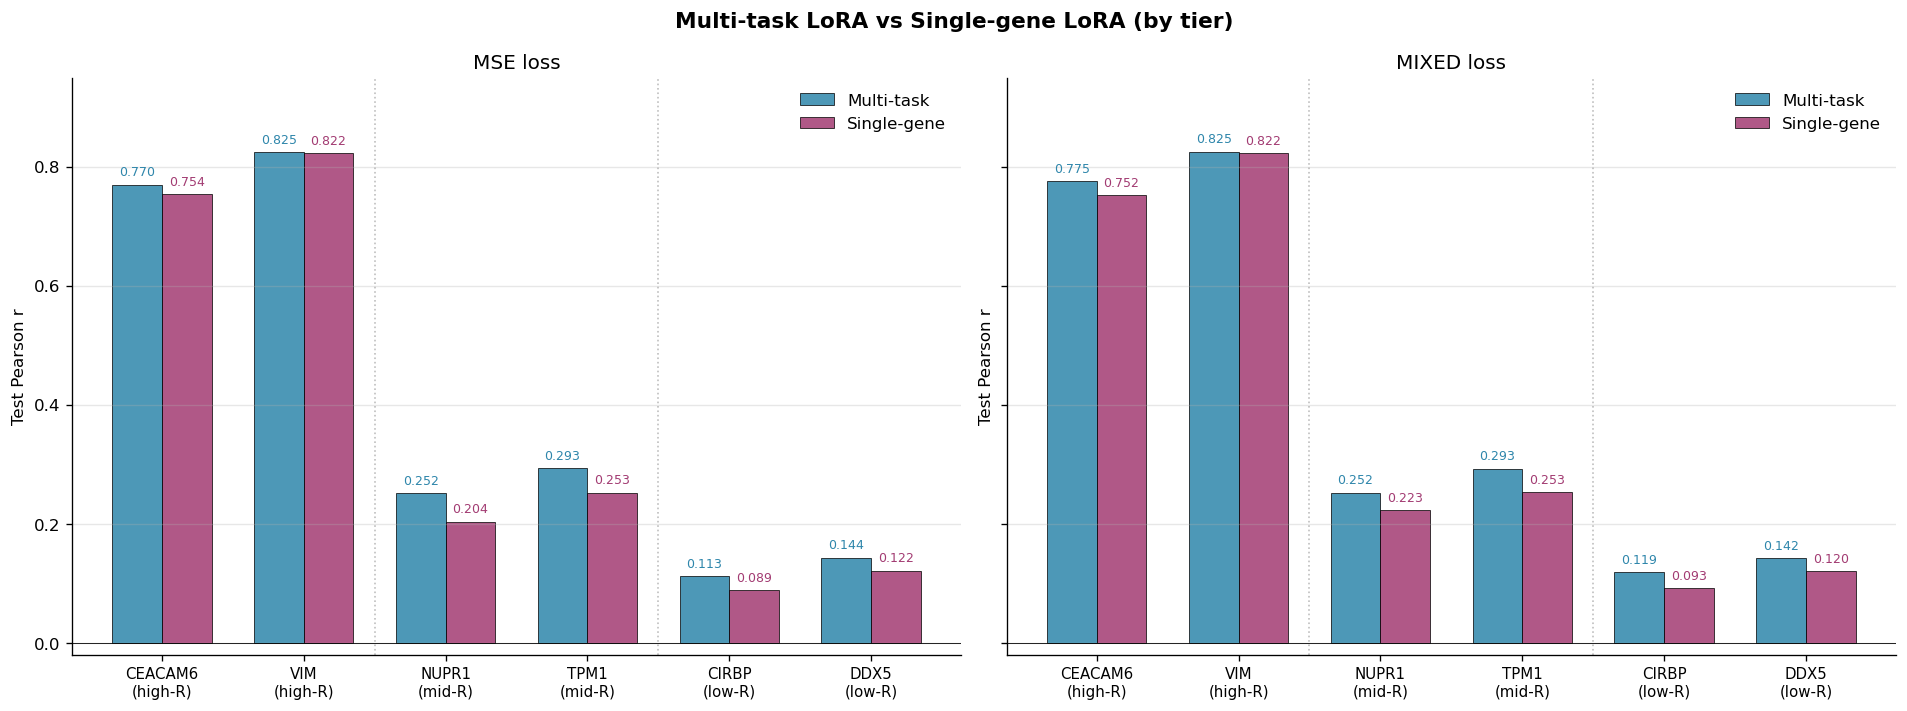

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (loss_label, _) in zip(axes, LOSS_VARIANTS.items()):
    sub = df[df['loss'] == loss_label].copy()
    sub['tier_rank'] = sub['tier'].map({t: i for i, t in enumerate(TIER_ORDER)})
    sub = sub.sort_values(['tier_rank', 'gene_name']).reset_index(drop=True)

    x     = np.arange(len(sub))
    width = 0.35

    multi_vals  = sub['multi_task_r'].fillna(0).values
    single_vals = sub['single_gene_r'].fillna(0).values

    b1 = ax.bar(x - width/2, multi_vals,  width, label='Multi-task',
                color='#2E86AB', alpha=0.85, edgecolor='black', lw=0.5)
    b2 = ax.bar(x + width/2, single_vals, width, label='Single-gene',
                color='#A23B72', alpha=0.85, edgecolor='black', lw=0.5)

    for bar, val in zip(b1, multi_vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.015,
                    f'{val:.3f}', ha='center', fontsize=7.5, color='#2E86AB')
    for bar, val in zip(b2, single_vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.015,
                    f'{val:.3f}', ha='center', fontsize=7.5, color='#A23B72')

    # Tier divider lines
    for i in range(1, len(sub)):
        if sub.iloc[i]['tier'] != sub.iloc[i-1]['tier']:
            ax.axvline(i - 0.5, color='gray', ls=':', lw=1, alpha=0.5)

    ax.set_xticks(x)
    gene_labels = [f'{r["gene_name"]}\n({r["tier"]})' for _, r in sub.iterrows()]
    ax.set_xticklabels(gene_labels, fontsize=9)
    ax.set_ylabel('Test Pearson r')
    ax.set_title(f'{loss_label.upper()} loss')
    ax.legend(loc='upper right')
    ax.axhline(0, color='black', lw=0.5)
    ax.grid(axis='y', alpha=0.3)

    ymax = max(max(multi_vals), max(single_vals), 0.1) * 1.15
    ax.set_ylim(-0.02, ymax)

fig.suptitle('Multi-task LoRA vs Single-gene LoRA (by tier)',
             fontweight='bold', fontsize=13)
fig.tight_layout()
plt.show()

## 7. Scatter — multi vs single (colored by tier)

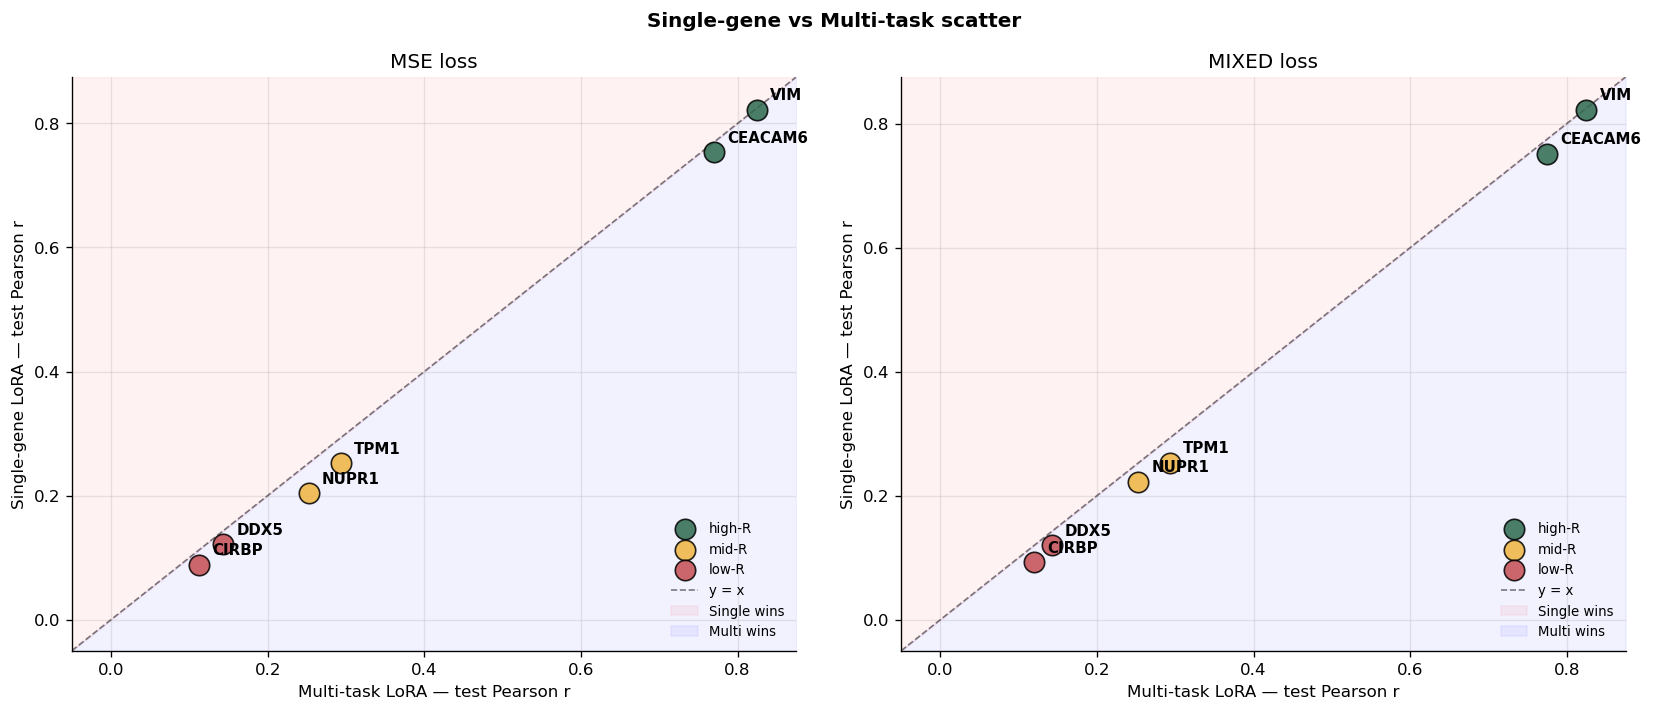

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (loss_label, _) in zip(axes, LOSS_VARIANTS.items()):
    sub = df[df['loss'] == loss_label].copy()
    sub = sub[sub['multi_task_r'].notna() & sub['single_gene_r'].notna()]

    for tier in TIER_ORDER:
        tier_sub = sub[sub['tier'] == tier]
        if len(tier_sub) == 0:
            continue
        ax.scatter(tier_sub['multi_task_r'], tier_sub['single_gene_r'],
                   s=150, color=TIER_COLORS[tier],
                   edgecolor='black', lw=1, alpha=0.85,
                   label=tier, zorder=3)

        for _, row in tier_sub.iterrows():
            ax.annotate(row['gene_name'],
                        xy=(row['multi_task_r'], row['single_gene_r']),
                        xytext=(8, 6), textcoords='offset points',
                        fontsize=9, fontweight='bold')

    lims = [-0.05, max(sub[['multi_task_r', 'single_gene_r']].max().max(), 0.5) + 0.05]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y = x')

    ax.fill_between(lims, lims, max(lims), alpha=0.05, color='red',
                    label='Single wins')
    ax.fill_between(lims, min(lims), lims, alpha=0.05, color='blue',
                    label='Multi wins')

    ax.set_xlabel('Multi-task LoRA — test Pearson r')
    ax.set_ylabel('Single-gene LoRA — test Pearson r')
    ax.set_title(f'{loss_label.upper()} loss')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = dict(zip(labels, handles))
    ax.legend(seen.values(), seen.keys(), loc='lower right', fontsize=8)

fig.suptitle('Single-gene vs Multi-task scatter',
             fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

## 8. Analysis by tier

In [10]:
tier_summary = (df.groupby(['tier', 'loss'])
                  .agg(multi_mean=('multi_task_r', 'mean'),
                       single_mean=('single_gene_r', 'mean'),
                       diff_mean=('diff', 'mean'),
                       n_genes=('gene_name', 'count'))
                  .round(4))
print('Aggregate by tier:\n')
print(tier_summary)

Aggregate by tier:

              multi_mean  single_mean  diff_mean  n_genes
tier   loss                                              
high-R mixed      0.8002       0.7869    -0.0132        2
       mse        0.7974       0.7880    -0.0094        2
low-R  mixed      0.1306       0.1066    -0.0240        2
       mse        0.1280       0.1052    -0.0228        2
mid-R  mixed      0.2726       0.2380    -0.0347        2
       mse        0.2728       0.2283    -0.0445        2


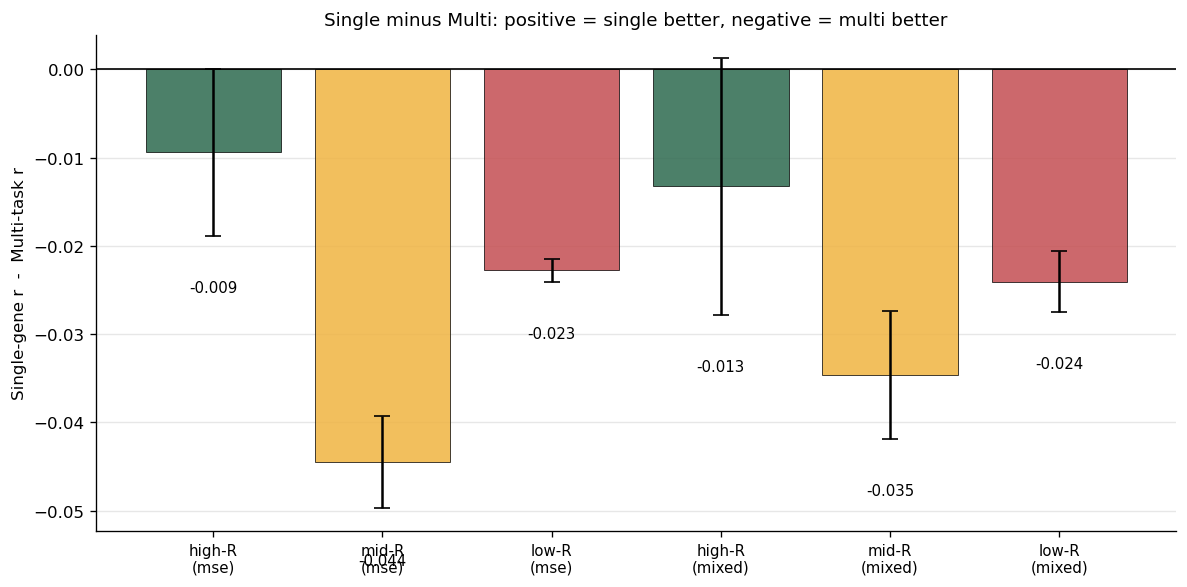

In [11]:
# Diff per tier bar chart
fig, ax = plt.subplots(figsize=(10, 5))

tier_labels = []
diff_means  = []
diff_errs   = []
colors      = []

for loss_label in LOSS_VARIANTS.keys():
    for tier in TIER_ORDER:
        sub = df[(df['loss'] == loss_label) & (df['tier'] == tier) & df['diff'].notna()]
        tier_labels.append(f'{tier}\n({loss_label})')
        diff_means.append(sub['diff'].mean() if len(sub) > 0 else 0)
        diff_errs.append(sub['diff'].std()   if len(sub) > 1 else 0)
        colors.append(TIER_COLORS[tier])

x = np.arange(len(tier_labels))
ax.bar(x, diff_means, yerr=diff_errs,
       color=colors, alpha=0.85, edgecolor='black', lw=0.5,
       capsize=5, zorder=2)

ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(tier_labels, fontsize=9)
ax.set_ylabel('Single-gene r  -  Multi-task r')
ax.set_title('Single minus Multi: positive = single better, negative = multi better',
             fontsize=11)
ax.grid(axis='y', alpha=0.3)

for i, (m, e) in enumerate(zip(diff_means, diff_errs)):
    y_off = 0.005 if m > 0 else -0.005
    ax.text(i, m + y_off + (e if m > 0 else -e),
            f'{m:+.3f}',
            ha='center', va='bottom' if m > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Summary and interpretation

In [12]:
print('='*70)
print(' FINAL SUMMARY: Multi-task LoRA vs Single-gene LoRA')
print('='*70)

valid_df = df[df['diff'].notna()]

if len(valid_df) == 0:
    print('\nNo complete comparisons available.')
else:
    print(f'\nTotal valid comparisons: {len(valid_df)} '
          f'({len(GENES_TO_COMPARE)} genes × {len(LOSS_VARIANTS)} losses)\n')

    print(f' Overall statistics:')
    print(f'   Mean diff (single - multi):  {valid_df["diff"].mean():+.4f}')
    print(f'   Median diff:                 {valid_df["diff"].median():+.4f}')
    print(f'   Max single advantage:        '
          f'{valid_df["diff"].max():+.4f}  '
          f'({valid_df.loc[valid_df["diff"].idxmax(), "gene_name"]})')
    print(f'   Max multi advantage:         '
          f'{valid_df["diff"].min():+.4f}  '
          f'({valid_df.loc[valid_df["diff"].idxmin(), "gene_name"]})')

    print(f'\n Win counts:')
    print(f'   Single wins (>+0.01): {(valid_df["diff"] > 0.01).sum()}/{len(valid_df)}')
    print(f'   Multi wins  (<-0.01): {(valid_df["diff"] < -0.01).sum()}/{len(valid_df)}')
    print(f'   Essentially tie:      {(valid_df["diff"].abs() <= 0.01).sum()}/{len(valid_df)}')

    print(f'\n By tier (average diff):')
    for tier in TIER_ORDER:
        tier_data = valid_df[valid_df['tier'] == tier]
        if len(tier_data) > 0:
            mean_d = tier_data['diff'].mean()
            winner = 'single wins' if mean_d > 0.01 else ('multi wins' if mean_d < -0.01 else 'tie')
            print(f'   {tier:<8}: {mean_d:+.4f} ({winner})')

    print(f'\n' + '='*70)
    print(f' INTERPRETATION')
    print(f'='*70)

    overall_diff = valid_df['diff'].mean()

    if abs(overall_diff) < 0.015:
        print(f'\n  → Overall: multi-task and single-gene perform similarly')
        print(f'    Implication: USE MULTI-TASK (same performance, 400x cheaper)')
    elif overall_diff > 0:
        print(f'\n  → Overall: single-gene systematically better')
        print(f'    Implication: per-gene specialization beats shared learning')
    else:
        print(f'\n  → Overall: multi-task systematically better')
        print(f'    Implication: shared backbone learning helps')

    print(f'\n  Tier-specific patterns:')
    for tier in TIER_ORDER:
        tier_data = valid_df[valid_df['tier'] == tier]
        if len(tier_data) == 0:
            continue
        mean_d = tier_data['diff'].mean()
        if abs(mean_d) < 0.015:
            insight = 'similar performance'
        elif mean_d > 0:
            insight = 'single-gene specialization helps'
        else:
            insight = 'multi-task sharing helps'
        print(f'    {tier:<8}: {insight} (diff = {mean_d:+.4f})')

out_path = PROJECT / 'experiments' / 'multi_vs_single_lora_comparison.csv'
df.to_csv(out_path, index=False)
print(f'\nSaved comparison → {out_path}')

 FINAL SUMMARY: Multi-task LoRA vs Single-gene LoRA

Total valid comparisons: 12 (6 genes × 2 losses)

 Overall statistics:
   Mean diff (single - multi):  -0.0248
   Median diff:                 -0.0236
   Max single advantage:        -0.0027  (VIM)
   Max multi advantage:         -0.0482  (NUPR1)

 Win counts:
   Single wins (>+0.01): 0/12
   Multi wins  (<-0.01): 10/12
   Essentially tie:      2/12

 By tier (average diff):
   high-R  : -0.0113 (multi wins)
   mid-R   : -0.0396 (multi wins)
   low-R   : -0.0234 (multi wins)

 INTERPRETATION

  → Overall: multi-task systematically better
    Implication: shared backbone learning helps

  Tier-specific patterns:
    high-R  : similar performance (diff = -0.0113)
    mid-R   : multi-task sharing helps (diff = -0.0396)
    low-R   : multi-task sharing helps (diff = -0.0234)

Saved comparison → /hpc/group/jilab/tc459/MorphPT/experiments/multi_vs_single_lora_comparison.csv
